🔄 Training Softmax Regression (4-class)...
Iteration 0: Cost = 1.0959
Iteration 500: Cost = 0.0358
Iteration 1000: Cost = 0.0313
Iteration 1500: Cost = 0.0294

✅ Training Complete!
📊 Final Cost: 0.0283
🎯 Training Accuracy: 99.00%

📊 Per-Class Performance:
   Class 0: 97.33% (75 samples)
   Class 1: 100.00% (75 samples)
   Class 2: 98.67% (75 samples)
   Class 3: 100.00% (75 samples)

🔢 Confusion Matrix:
[[73  0  2  0]
 [ 0 75  0  0]
 [ 1  0 74  0]
 [ 0  0  0 75]]


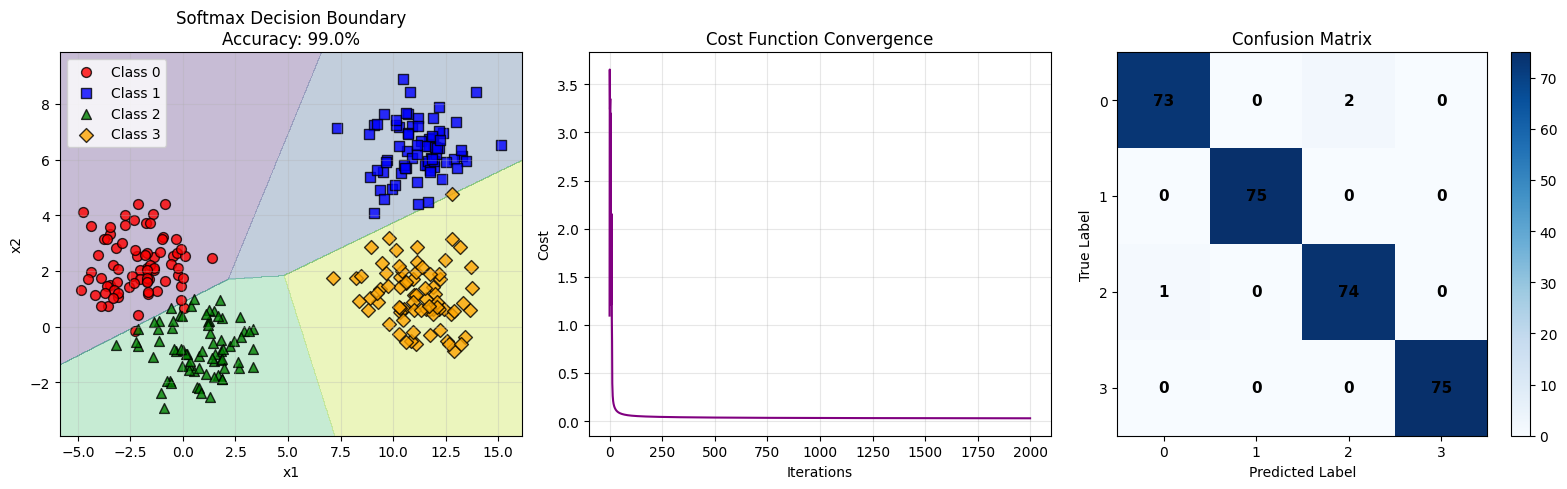


🔍 Example Predictions:
  Point (10.00,  5.00) → Class 1 [Probs: [1.35143151e-06 9.97389945e-01 2.16840126e-07 2.60848656e-03]]
  Point ( 1.00, -1.00) → Class 2 [Probs: [4.33005919e-07 8.89890237e-07 9.99272502e-01 7.26175180e-04]]
  Point (-2.00,  3.00) → Class 0 [Probs: [9.99980602e-01 1.93905046e-05 7.08080457e-09 7.59268338e-13]]
  Point (12.00,  1.00) → Class 3 [Probs: [1.20133974e-17 1.00721666e-07 5.19702329e-05 9.99947929e-01]]

📋 PROBLEM 3 - MODEL SUMMARY
• Algorithm:        Softmax Regression (Multinomial Logistic)
• Classes:          4 (0, 1, 2, 3)
• Input Features:   2 (x1, x2) + bias term
• Parameters:       12 weights (3 × 4 matrix)
• Training Samples: 300
• Training Accuracy: 99.00%
• Loss Function:    Multiclass Cross-Entropy
• Optimization:     Gradient Descent (from scratch)
• Learning Rate:    0.5
• Iterations:       2000


In [3]:
# ============================================================================
# PROBLEM 3: Multiclass (4-Class) Softmax Regression - FROM SCRATCH
# Dataset: data_3_2.csv
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# ============================================================================
# 1. LOAD AND PREPARE DATA
# ============================================================================
df = pd.read_csv('data_3_2.csv')
X = df[['x1', 'x2']].values
y = df['class'].values  # Labels: 0, 1, 2, 3
m = len(y)
n_features = 2
n_classes = 4

# Add bias term (x0 = 1)
X_b = np.c_[np.ones((m, 1)), X]  # Shape: (m, 3)

# One-hot encode labels for softmax
def one_hot_encode(y, n_classes):
    one_hot = np.zeros((len(y), n_classes))
    one_hot[np.arange(len(y)), y] = 1
    return one_hot

Y_onehot = one_hot_encode(y, n_classes)  # Shape: (m, 4)

# ============================================================================
# 2. SOFTMAX REGRESSION FUNCTIONS (From Scratch)
# ============================================================================

def softmax(z):
    """Numerically stable softmax function"""
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def compute_cost(X, Y, theta):
    """Cross-entropy loss for multiclass classification"""
    probs = softmax(X @ theta)
    epsilon = 1e-5
    cost = -np.mean(np.sum(Y * np.log(probs + epsilon), axis=1))
    return cost

def gradient_descent_softmax(X, Y, theta, lr, iterations):
    """Train softmax regression using gradient descent"""
    cost_history = []
    for i in range(iterations):
        # Forward pass
        probs = softmax(X @ theta)  # Shape: (m, n_classes)
        
        # Compute gradient: (1/m) * X^T * (probs - Y)
        gradient = (1 / len(Y)) * (X.T @ (probs - Y))
        
        # Update parameters
        theta = theta - lr * gradient
        
        # Record cost
        cost = compute_cost(X, Y, theta)
        cost_history.append(cost)
        
        if i % 500 == 0:
            print(f"Iteration {i}: Cost = {cost:.4f}")
    
    return theta, cost_history

def predict(X, theta):
    """Predict class labels"""
    probs = softmax(X @ theta)
    return np.argmax(probs, axis=1)

# ============================================================================
# 3. TRAIN THE MODEL
# ============================================================================
print("🔄 Training Softmax Regression (4-class)...")

# Initialize parameters: (n_features+1, n_classes) = (3, 4)
theta = np.random.randn(n_features + 1, n_classes) * 0.01

# Hyperparameters
learning_rate = 0.5
iterations = 2000

# Train
theta_opt, costs = gradient_descent_softmax(X_b, Y_onehot, theta, learning_rate, iterations)

print(f"\n✅ Training Complete!")
print(f"📊 Final Cost: {costs[-1]:.4f}")

# ============================================================================
# 4. EVALUATE MODEL
# ============================================================================

# Make predictions
y_pred = predict(X_b, theta_opt)

# Calculate overall accuracy
accuracy = np.mean(y_pred == y) * 100
print(f"🎯 Training Accuracy: {accuracy:.2f}%")

# Per-class accuracy
print("\n📊 Per-Class Performance:")
for cls in range(n_classes):
    mask = (y == cls)
    if np.sum(mask) > 0:
        cls_acc = np.mean(y_pred[mask] == cls) * 100
        print(f"   Class {cls}: {cls_acc:.2f}% ({np.sum(mask)} samples)")

# Confusion Matrix
print("\n🔢 Confusion Matrix:")
conf_matrix = np.zeros((n_classes, n_classes), dtype=int)
for true, pred in zip(y, y_pred):
    conf_matrix[true, pred] += 1
print(conf_matrix)

# ============================================================================
# 5. VISUALIZATION
# ============================================================================

plt.figure(figsize=(16, 5))

# --- Plot 1: Decision Boundary ---
plt.subplot(1, 3, 1)
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), 
                     np.arange(y_min, y_max, h))

# Create grid with bias term
grid_b = np.c_[np.ones((xx.ravel().shape[0], 1)), xx.ravel(), yy.ravel()]

# Predict class for each point in grid
probs_grid = softmax(grid_b @ theta_opt)
Z = np.argmax(probs_grid, axis=1).reshape(xx.shape)

# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis', levels=n_classes)

# Scatter plot of actual data
colors = ['red', 'blue', 'green', 'orange']
markers = ['o', 's', '^', 'D']
for cls in range(n_classes):
    plt.scatter(X[y == cls][:, 0], X[y == cls][:, 1], 
               c=[colors[cls]], label=f'Class {cls}', 
               marker=markers[cls], edgecolors='k', alpha=0.8, s=50)

plt.xlabel('x1')
plt.ylabel('x2')
plt.title(f'Softmax Decision Boundary\nAccuracy: {accuracy:.1f}%')
plt.legend()
plt.grid(alpha=0.3)

# --- Plot 2: Cost Convergence ---
plt.subplot(1, 3, 2)
plt.plot(costs, color='purple', linewidth=1.5)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost Function Convergence')
plt.grid(alpha=0.3)

# --- Plot 3: Confusion Matrix Heatmap ---
plt.subplot(1, 3, 3)
im = plt.imshow(conf_matrix, cmap='Blues', aspect='auto')
plt.colorbar(im)
for i in range(n_classes):
    for j in range(n_classes):
        plt.text(j, i, str(conf_matrix[i, j]), 
                ha='center', va='center', fontsize=11, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(range(n_classes))
plt.yticks(range(n_classes))

plt.tight_layout()
plt.savefig('problem3_softmax_results.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 6. PREDICTION FUNCTION FOR NEW DATA
# ============================================================================

def predict_multiclass(x1_new, x2_new, theta):
    """Predict class and probabilities for new input values"""
    x_new = np.array([[1, x1_new, x2_new]])  # Shape: (1, 3)
    probs = softmax(x_new @ theta)[0]  # Shape: (4,)
    pred_class = np.argmax(probs)
    return pred_class, probs

# Example predictions
print("\n🔍 Example Predictions:")
test_points = [(10.0, 5.0), (1.0, -1.0), (-2.0, 3.0), (12.0, 1.0)]
for x1_test, x2_test in test_points:
    pred_cls, probs = predict_multiclass(x1_test, x2_test, theta_opt)
    print(f"  Point ({x1_test:5.2f}, {x2_test:5.2f}) → Class {pred_cls} " + 
          f"[Probs: {probs}]")

# ============================================================================
# 7. MODEL SUMMARY
# ============================================================================

print("\n" + "="*60)
print("📋 PROBLEM 3 - MODEL SUMMARY")
print("="*60)
print(f"• Algorithm:        Softmax Regression (Multinomial Logistic)")
print(f"• Classes:          4 (0, 1, 2, 3)")
print(f"• Input Features:   2 (x1, x2) + bias term")
print(f"• Parameters:       {theta_opt.size} weights (3 × 4 matrix)")
print(f"• Training Samples: {m}")
print(f"• Training Accuracy: {accuracy:.2f}%")
print(f"• Loss Function:    Multiclass Cross-Entropy")
print(f"• Optimization:     Gradient Descent (from scratch)")
print(f"• Learning Rate:    {learning_rate}")
print(f"• Iterations:       {iterations}")
print("="*60)